# Coffee Sales Analysis 

In [92]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

### Loading and Inspecting Dataset

In [93]:
df = pd.read_csv('Coffee Shop Sales.csv')

In [94]:
df.head(5)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,1/1/23,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,1/1/23,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,1/1/23,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,1/1/23,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,1/1/23,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [95]:
df.describe()

,transaction_id,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.542509,2.074241,17.930020,2.658723
min,1.000000,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2.000000,8.000000,60.000000,3.750000
max,149456.000000,8.000000,8.000000,87.000000,45.000000


In [96]:
df.isnull().sum()
# no missing values

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [97]:
# checking each features data type
print(df.dtypes)

transaction_id        int64
transaction_date     object
transaction_time     object
transaction_qty       int64
store_id              int64
store_location       object
product_id            int64
unit_price          float64
product_category     object
product_type         object
product_detail       object
dtype: object


### Basic Cleaning

In [99]:
# drop id columns (major irrelevance to model)
df = df.drop(columns=["transaction_id", "product_id", "store_id", "product_detail", "product_category"])

In [100]:
# convert transaction date and transaction time to datetype format
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

/var/folders/3q/jht5y2bd17g9fcxq1v6zw9bw0000gn/T/ipykernel_47938/500131734.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['transaction_date'] = pd.to_datetime(df['transaction_date'])


In [101]:
# converting transaction date to datetime 
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [102]:
# Extract Month
df['month'] = df['transaction_date'].dt.month

# Function to assign month to a season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df['season'] = df['month'].apply(get_season)

In [103]:
# create revenue column for analysis 
df['revenue$'] = df['unit_price'] * df['transaction_qty']

### Descriptive Analysis

__Top products by revenue per season__

In [104]:
df.groupby("season")[["product_type", "revenue$"]].apply(lambda x: x.groupby("product_type")["revenue$"].sum().sort_values(ascending=False).head(5))


season  product_type         
Spring  Barista Espresso         49057.85
        Brewed Chai tea          41748.95
        Hot chocolate            38840.00
        Gourmet brewed coffee    37168.80
        Brewed Black tea         25676.50
Summer  Barista Espresso         21860.00
        Brewed Chai tea          18188.15
        Gourmet brewed coffee    17142.00
        Hot chocolate            17106.00
        Brewed Black tea         11350.50
Winter  Barista Espresso         20488.35
        Brewed Chai tea          17144.85
        Hot chocolate            16470.00
        Gourmet brewed coffee    15723.80
        Brewed Black tea         10905.00
Name: revenue$, dtype: float64

__Top revenue generators per location:__

In [105]:
df.groupby("store_location")[["product_type", "revenue$"]].apply(lambda x: x.groupby("product_type")["revenue$"].sum().sort_values(ascending=False).head(5))

store_location   product_type         
Astoria          Barista Espresso         27935.00
                 Brewed Chai tea          27427.90
                 Hot chocolate            26335.25
                 Gourmet brewed coffee    23823.30
                 Brewed herbal tea        16282.00
Hell's Kitchen   Barista Espresso         32420.20
                 Brewed Chai tea          25645.30
                 Hot chocolate            23586.25
                 Gourmet brewed coffee    23010.10
                 Brewed Black tea         15575.50
Lower Manhattan  Barista Espresso         31051.00
                 Brewed Chai tea          24008.75
                 Gourmet brewed coffee    23201.20
                 Hot chocolate            22494.50
                 Brewed Black tea         16215.50
Name: revenue$, dtype: float64

__Total Revenue per season__

In [106]:
df.groupby("season")["revenue$"].sum().sort_values(ascending=False)

season
Spring    374503.52
Summer    166485.88
Winter    157822.93
Name: revenue$, dtype: float64

__Seasonal Product Popularity Heatmap__

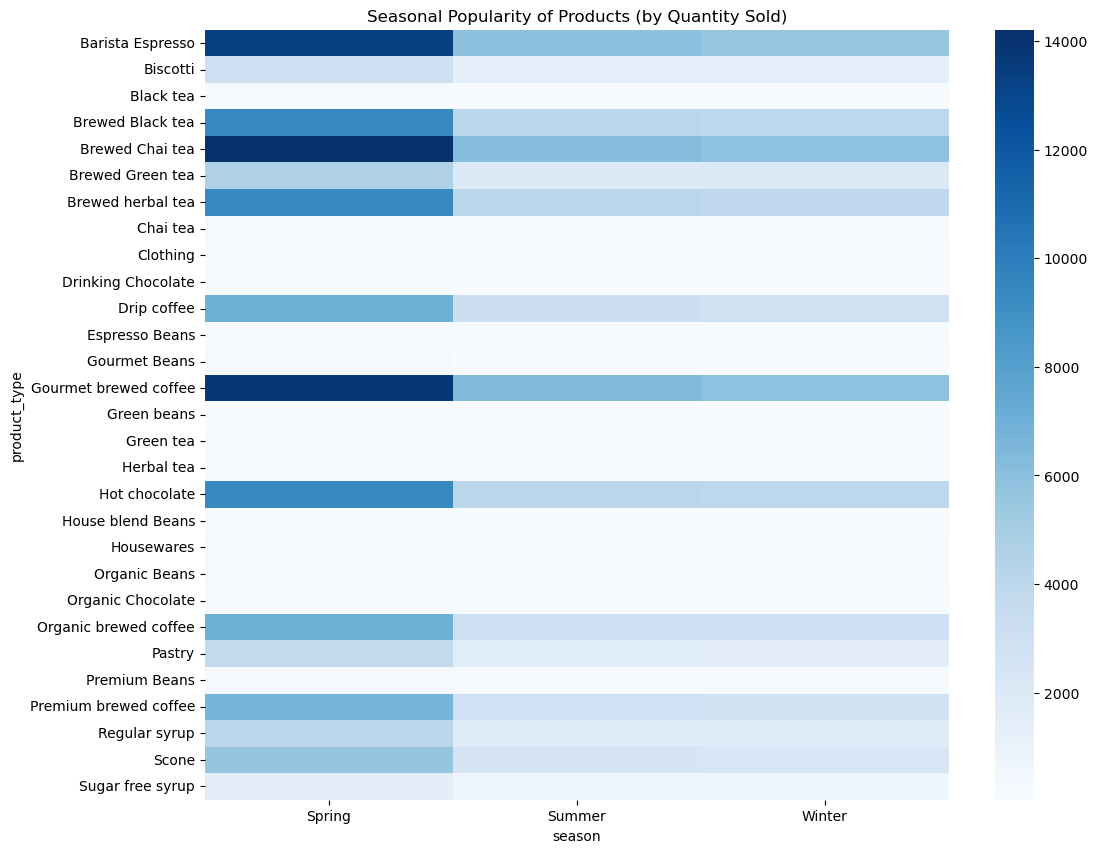

In [107]:
season_product_pivot = df.pivot_table(
    index="product_type",
    columns="season",
    values="transaction_qty",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(12, 10))
sns.heatmap(season_product_pivot, cmap="Blues")
plt.title("Seasonal Popularity of Products (by Quantity Sold)")
plt.show()

### Model Pre-processing

In [108]:
# defining features and target 
y = df["product_type"]
X = df.drop(columns=["product_type"])

In [109]:
# defining numerical and categorical values 
categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

In [110]:
# one hot encoding and scaling 
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numeric_cols)
])

In [111]:
# PREPROCESSING PIPELINE
logreg = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000, n_jobs=-1))
])

rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300))
])

### Training the models

For this analysis, I am using the following models to make predicitons on which product is the most popular according to each season:

___1. Multiclass Logistic Regression___

___2. Random Forest Classifier___


In [112]:
# Splitting the data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [113]:
# training all 3 models 

# Logistic Regression
log_reg_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

# Random Forest
rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42))
])


In [120]:
# fit models
log_reg_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [121]:
# Evaluation Function

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n----- {name} -----")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="weighted"))
    print("Recall:", recall_score(y_test, y_pred, average="weighted"))
    print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
    
    return y_pred

### Evaluate Models

In [122]:
pred_logreg = evaluate_model("Logistic Regression", logreg)
pred_rf = evaluate_model("Random Forest", rf)


----- Logistic Regression -----
Accuracy: 0.7019849785407726
Precision: 0.7103095176263945
Recall: 0.7019849785407726
F1 Score: 0.7004953001084077

----- Random Forest -----
Accuracy: 0.9173484442060086
Precision: 0.9216735725160863
Recall: 0.9173484442060086
F1 Score: 0.9179734768262515


___Comments___

__The random forest classfier performed way better than the logistic regression model. With a stunning accuracy of 91.7 %, and an F1 Score of 91.8%. The coffee shop can use the Random Forest Model for furture predictions.__

### Prediction Distribution

Top Predicted Product Types:
Brewed Chai tea          3806
Gourmet brewed coffee    3431
Barista Espresso         3280
Brewed Black tea         2209
Brewed herbal tea        2201
Hot chocolate            2109
Scone                    1980
Pastry                   1634
Drip coffee              1572
Organic brewed coffee    1546
Name: count, dtype: int64


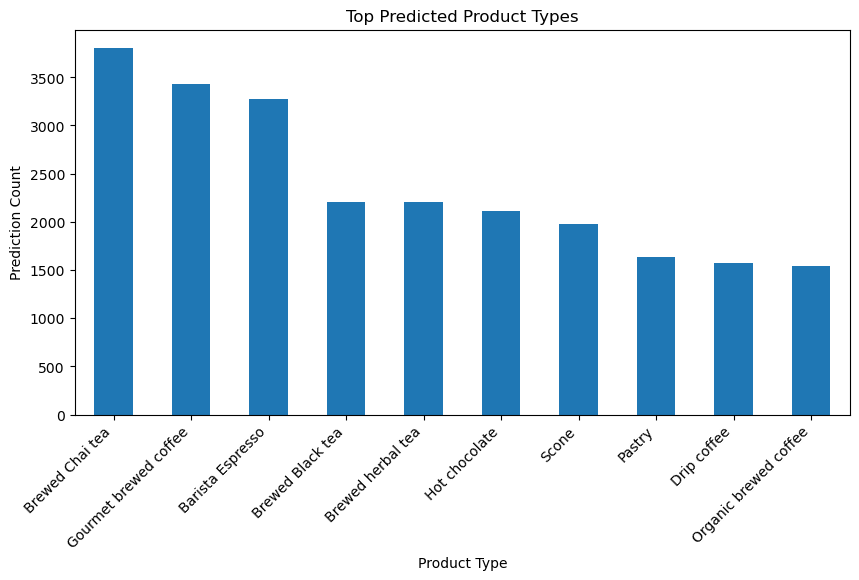

In [123]:
best_model = rf_clf

# Make predictions
y_pred = best_model.predict(X_test)

# Distribution of predicted classes
pred_dist = pd.Series(y_pred).value_counts().head(10)

print("Top Predicted Product Types:")
print(pred_dist)

# Plot
pred_dist.plot(kind="bar", figsize=(10,5))
plt.title("Top Predicted Product Types")
plt.xlabel("Product Type")
plt.ylabel("Prediction Count")
plt.xticks(rotation=45, ha='right')
plt.show()

### Prediciton by Season

In [125]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df.drop(columns=["product_type"]),
    df["product_type"],
    test_size=0.2,
    random_state=42,
    stratify=df["product_type"]
)


In [130]:
# Combine predictions with season column
pred_df = pd.DataFrame({
    "season": X_test_raw["season"],
    "true": y_test,
    "predicted": y_pred
})

# Count top 5 predicted product types per season
pred_by_season = (
    pred_df.groupby("season")["predicted"]
    .value_counts()
    .groupby(level=0).head(10)
)

print(pred_by_season)

season  predicted            
Spring  Brewed Chai tea          2049
        Gourmet brewed coffee    1843
        Barista Espresso         1795
        Brewed Black tea         1194
        Hot chocolate            1152
        Brewed herbal tea        1149
        Scone                    1071
        Pastry                    889
        Organic brewed coffee     863
        Drip coffee               847
Summer  Brewed Chai tea           937
        Gourmet brewed coffee     839
        Barista Espresso          757
        Brewed herbal tea         522
        Brewed Black tea          502
        Hot chocolate             492
        Scone                     453
        Pastry                    402
        Drip coffee               376
        Organic brewed coffee     338
Winter  Brewed Chai tea           820
        Gourmet brewed coffee     749
        Barista Espresso          728
        Brewed herbal tea         530
        Brewed Black tea          513
        Hot chocolat

### Visual (top predictions by season)

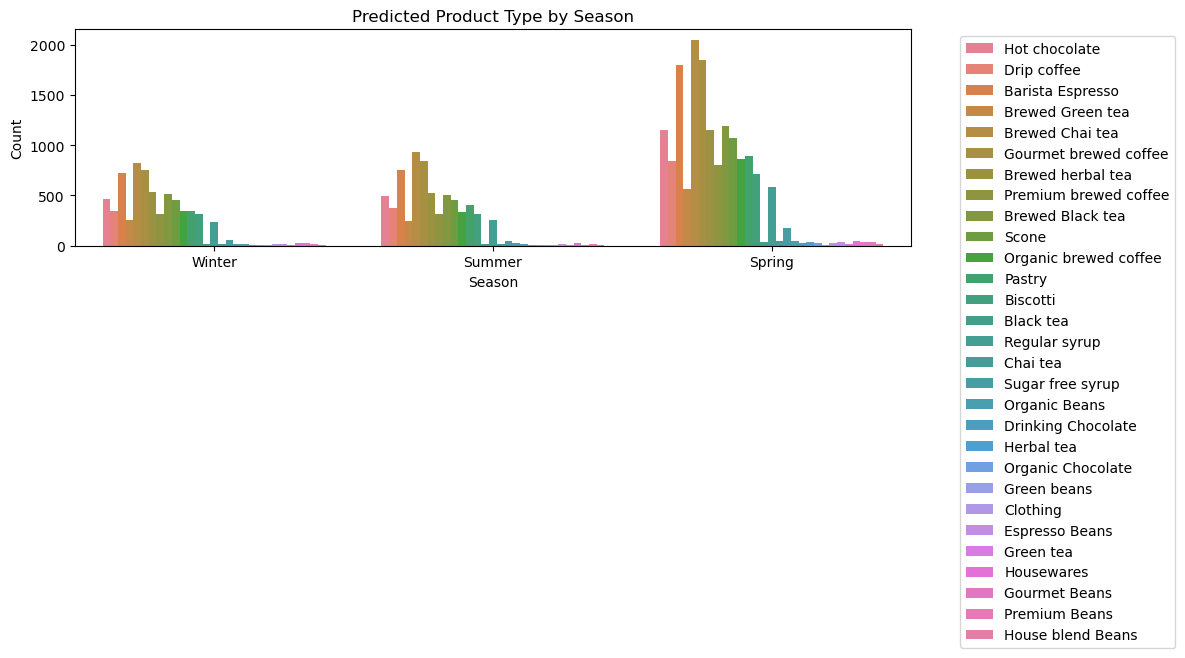

In [127]:
plt.figure(figsize=(12,5))
sns.countplot(data=pred_df, x="season", hue="predicted")
plt.title("Predicted Product Type by Season")
plt.xlabel("Season")
plt.ylabel("Count")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot for Analysis 

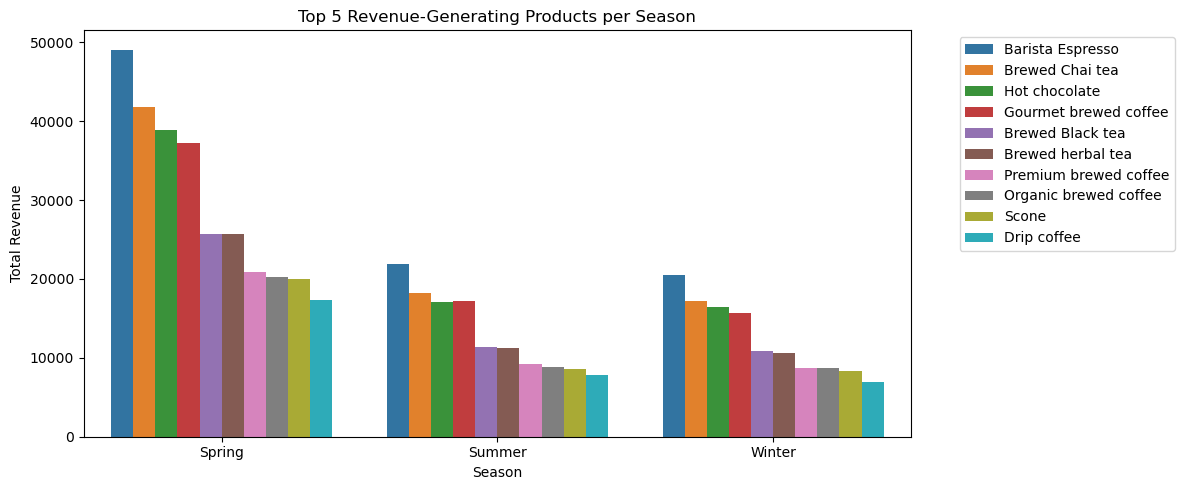

In [129]:
top_products = (
    df.groupby(["season", "product_type"])["revenue$"]
      .sum()
      .reset_index()
)

# Select top 5 per season
top_products = (
    top_products.sort_values(["season", "revenue$"], ascending=[True, False])
                .groupby("season")
                .head(10)
)

plt.figure(figsize=(12,5))
sns.barplot(data=top_products, x="season", y="revenue$", hue="product_type")
plt.title("Top 5 Revenue-Generating Products per Season")
plt.ylabel("Total Revenue")
plt.xlabel("Season")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()